In [1]:
%cd ~/
!git clone https://github.com/RudenkoBogdan/theory_nn.git
%cd theory_nn/california_housing
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    font_scale=1,
    palette="muted"
)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#2c3e50",
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

/root
fatal: destination path 'theory_nn' already exists and is not an empty directory.
/root/theory_nn/california_housing


In [2]:
import numpy as np
from src import dataset, scaler, linear_regression, regressor

In [3]:
data = dataset.Data()
scaler = scaler.Scaler()
X_train, X_test, y_train, y_test = data.split()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Text(0.5, 1.0, 'Loss на трейне - линейная регрессия')

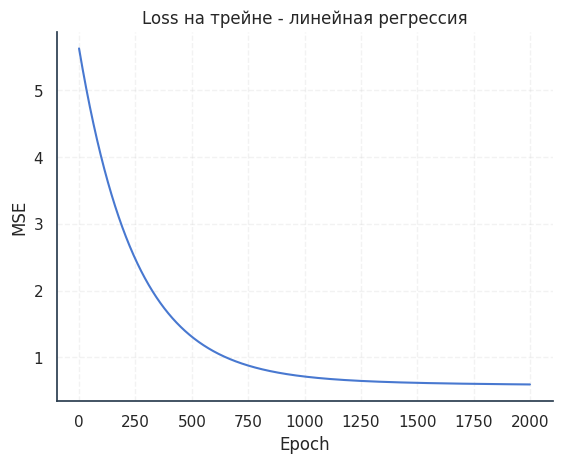

In [5]:
LR = linear_regression.LinearRegression()
history = LR.fit(X_train, y_train)

sns.lineplot(history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss на трейне - линейная регрессия")

Epoch 0 
Loss 5.0596763157794795
Epoch 50 
Loss 1.1821728856015734
Epoch 100 
Loss 0.9515707151695763
Epoch 150 
Loss 0.8713760842716417
Epoch 200 
Loss 0.8329774607457989
Epoch 250 
Loss 0.8088156082295015
Epoch 300 
Loss 0.7902147482584799
Epoch 350 
Loss 0.7741549565914742
Epoch 400 
Loss 0.7596842078608802
Epoch 450 
Loss 0.7463763061433788
Epoch 500 
Loss 0.7340041033339568
Epoch 550 
Loss 0.7224511317091579
Epoch 600 
Loss 0.7116248861635709
Epoch 650 
Loss 0.7014251181701109
Epoch 700 
Loss 0.6917950749903465
Epoch 750 
Loss 0.6826833133675527
Epoch 800 
Loss 0.6740367839701736
Epoch 850 
Loss 0.6658034562799732
Epoch 900 
Loss 0.6579647220849173
Epoch 950 
Loss 0.6504934524908166
Epoch 1000 
Loss 0.6433712946422981
Epoch 1050 
Loss 0.6365455227182263
Epoch 1100 
Loss 0.6299884008865904
Epoch 1150 
Loss 0.6236644857110771
Epoch 1200 
Loss 0.6175644578325516
Epoch 1250 
Loss 0.611672427490941
Epoch 1300 
Loss 0.6059731720786495
Epoch 1350 
Loss 0.6004742882559085
Epoch 1400 
Loss

Text(0.5, 1.0, 'Loss на трейне - ReLU регрессор')

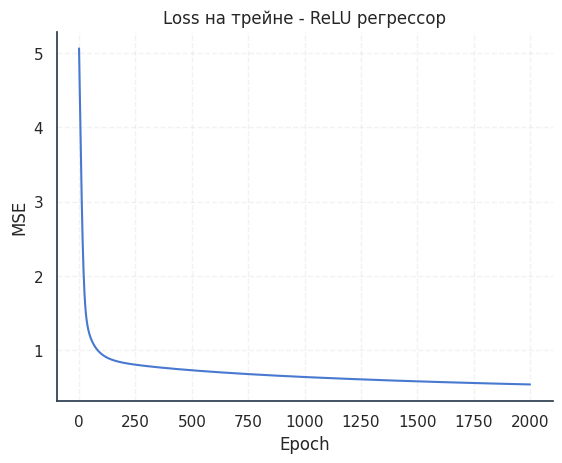

In [6]:
model = regressor.Regressor()
nn_history = model.fit(X_train, y_train)

sns.lineplot(nn_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss на трейне - ReLU регрессор")

In [49]:
lr_pred = np.asarray(LR.predict(X_test)).flatten()
nn_pred = np.asarray(model.predict(X_test)).flatten()
y_test = np.asarray(y_test).flatten()

In [54]:
lr_mse = np.sum((y_test - lr_pred)**2) / len(lr_pred)
nn_mse = np.sum((y_test - nn_pred)**2) / len(nn_pred)
lr_rmse = np.sqrt(lr_mse) 
nn_rmse = np.sqrt(nn_mse)

In [57]:
print('lr mse', round(lr_mse, 4))
print('nn mse', round(nn_mse, 4))
print('lr rmse', round(lr_rmse, 4))
print('nn rmse', round(nn_rmse, 4))

lr mse 0.6071
nn mse 0.5628
lr rmse 0.7792
nn rmse 0.7502


/tmp/ipykernel_27308/1020672984.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, 0].boxplot(box_data, labels=['Линейная регрессия', 'Нейросеть'])


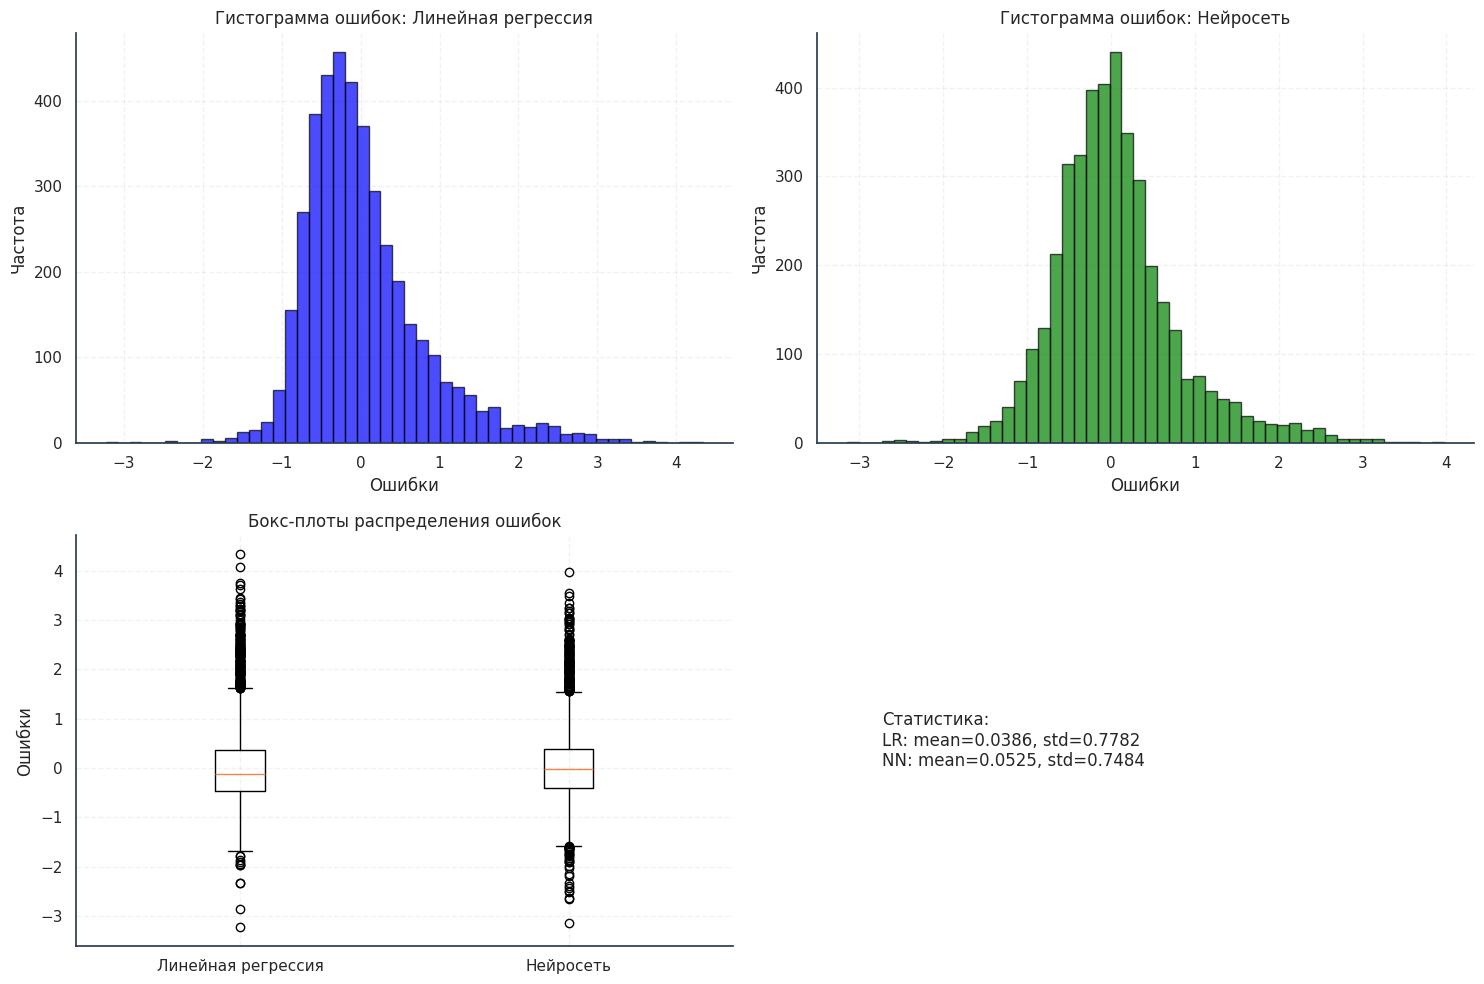

In [ ]:

residuals_lr = y_test - lr_pred
residuals_nn = y_test - nn_pred  

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs[0, 0].hist(residuals_lr, bins=50, alpha=0.7, edgecolor='black', color='blue')
axs[0, 0].set_xlabel('Ошибки')
axs[0, 0].set_ylabel('Частота')
axs[0, 0].set_title('Гистограмма ошибок: Линейная регрессия')
axs[0, 0].grid(True)

axs[0, 1].hist(residuals_nn, bins=50, alpha=0.7, edgecolor='black', color='green')
axs[0, 1].set_xlabel('Ошибки')
axs[0, 1].set_ylabel('Частота')
axs[0, 1].set_title('Гистограмма ошибок: Нейросеть')
axs[0, 1].grid(True)

box_data = [residuals_lr, residuals_nn]
axs[1, 0].boxplot(box_data, labels=['Линейная регрессия', 'Нейросеть'])
axs[1, 0].set_ylabel('Ошибки')
axs[1, 0].set_title('Бокс-плоты распределения ошибок')
axs[1, 0].grid(True)

axs[1, 1].axis('off')
stats_text = f"""Статистика:
LR: mean={np.mean(residuals_lr):.4f}, std={np.std(residuals_lr):.4f}
NN: mean={np.mean(residuals_nn):.4f}, std={np.std(residuals_nn):.4f}"""
axs[1, 1].text(0.1, 0.5, stats_text, fontsize=22, verticalalignment='center')

plt.tight_layout()
plt.show()
